## Dependencies

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import getpass
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Load/Clean Data

In [26]:
# 1. Load the data
df = pd.read_csv('Access_to_Care_Dataset.csv')

# Remove rows where ESTIMATE is missing
before_count = len(df)
df = df.dropna(subset=['ESTIMATE'])
removed = before_count - len(df)
print(f"Removed {removed:,} rows with missing ESTIMATE values ({removed/before_count*100:.1f}%)")

# Data type optimization
df['TIME_PERIOD'] = df['TIME_PERIOD'].astype('int16')
df['ESTIMATE'] = df['ESTIMATE'].astype('float32')
df['ESTIMATE_LCI'] = df['ESTIMATE_LCI'].astype('float32')
df['ESTIMATE_UCI'] = df['ESTIMATE_UCI'].astype('float32')

# Check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows")
    df = df.drop_duplicates()
    print(f"Removed duplicates")
else:
    print("No duplicate rows found")

Removed 2,369 rows with missing ESTIMATE values (9.0%)
No duplicate rows found


## Topic Correlation 2023

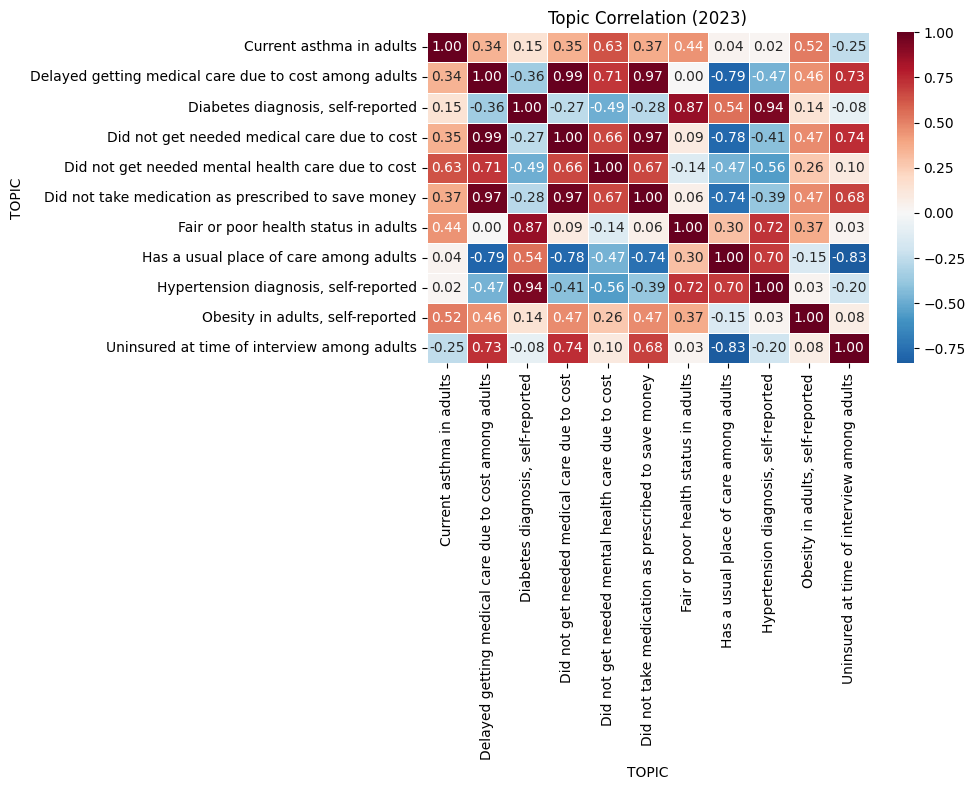

In [27]:
target_topics = [
    'Delayed getting medical care due to cost among adults',
    'Did not get needed medical care due to cost',
    'Did not get needed mental health care due to cost',
    'Did not take medication as prescribed to save money',
    'Has a usual place of care among adults',
    'Diabetes diagnosis, self-reported',
    'Hypertension diagnosis, self-reported',
    'Obesity in adults, self-reported',
    'Current asthma in adults',
    'Fair or poor health status in adults',
    'Uninsured at time of interview among adults'
]
df_2023 = df[(df['TIME_PERIOD'] == 2023) & (df['TOPIC'].isin(target_topics))].copy()
df_2023['Profile'] = df_2023['CLASSIFICATION'] + " | " + df_2023['GROUP'] + " | " + df_2023['SUBGROUP']

# Handle nesting (e.g., distinguishing "Employed" from "Employed - Full-time")
df_2023['Profile'] = df_2023.apply(
    lambda x: x['Profile'] + " (" + str(x['NESTING_LABEL']) + ")" if pd.notnull(x['NESTING_LABEL']) else x['Profile'], axis=1
)

topic_df = df_2023.pivot_table(index='Profile', columns='TOPIC', values='ESTIMATE')
corr = topic_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr,
            annot=True,          # Show the numbers on the plot
            fmt=".2f",           # Round to 2 decimal places
            cmap='RdBu_r',       # Red-Blue color map (good for correlation)
            center=0,            # Center the color bar at 0
            linewidths=0.5)

plt.title('Topic Correlation (2023)')
plt.tight_layout()

## Topic Clustering

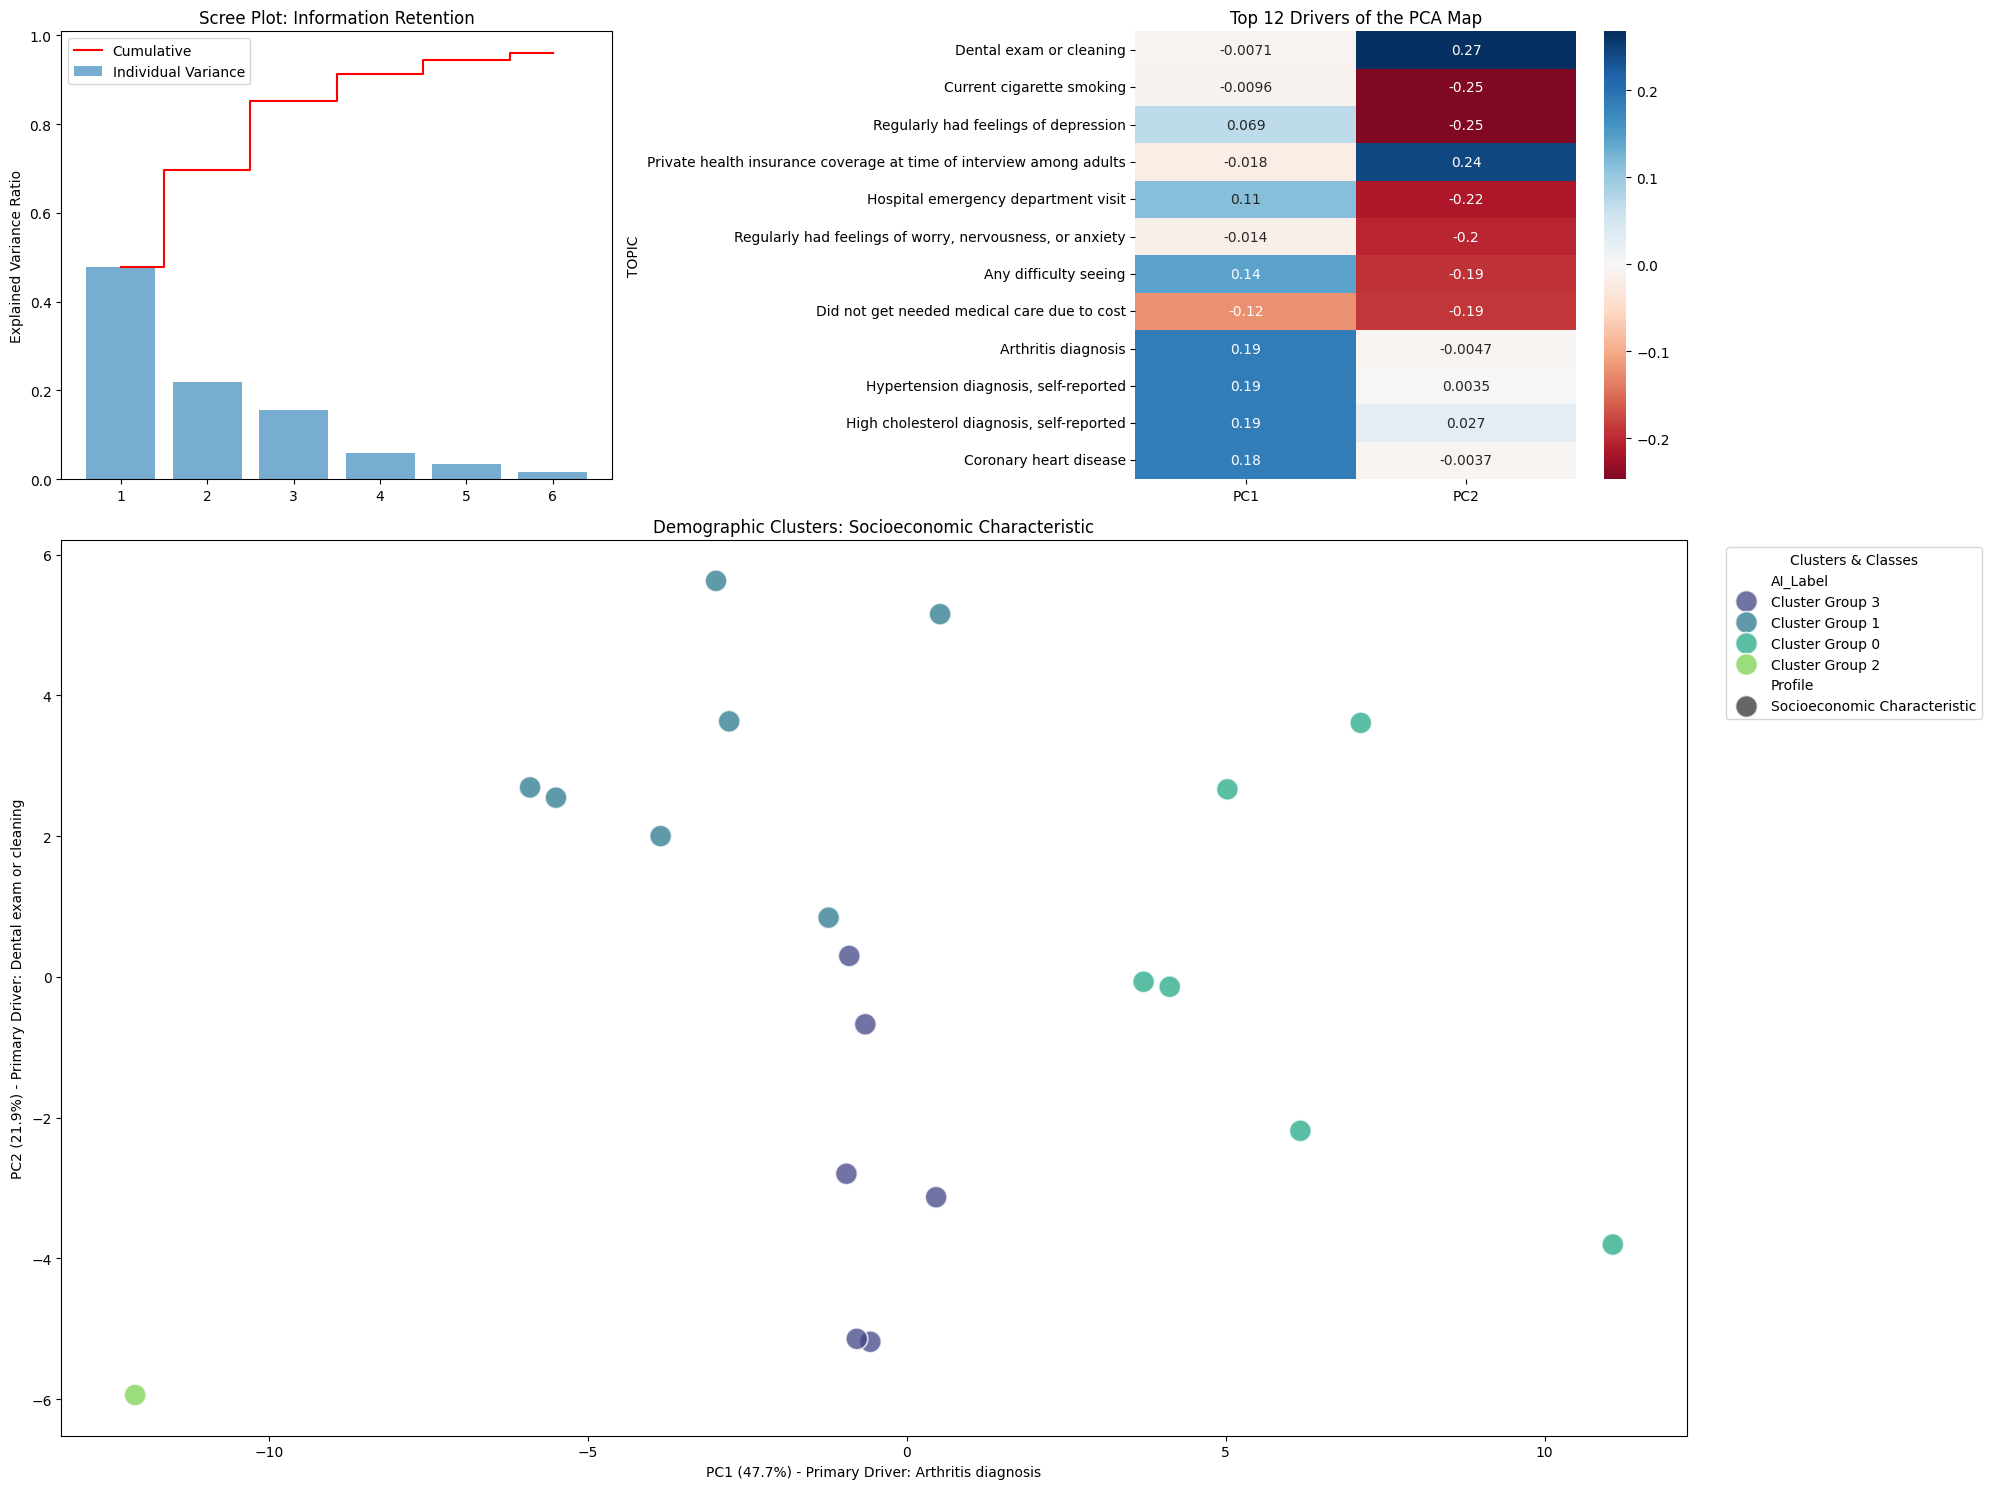


--- Cluster Group 0 (Cluster 0) ---
 • Socioeconomic Characteristic | Medicare Advantage
 • Socioeconomic Characteristic | Medicare and Medicaid
 • Socioeconomic Characteristic | Medicare only excluding Medicare Advantage
 • Socioeconomic Characteristic | Not employed (Not employed)
 • Socioeconomic Characteristic | Not employed - Has worked previously (Not employed)
 • Socioeconomic Characteristic | Other government coverage

--- Cluster Group 1 (Cluster 1) ---
 • Socioeconomic Characteristic | College degree or higher
 • Socioeconomic Characteristic | Employed (Employed)
 • Socioeconomic Characteristic | Employed - Full-time (Employed)
 • Socioeconomic Characteristic | Employed - Part-time (Employed)
 • Socioeconomic Characteristic | Not employed - Has never worked (Not employed)
 • Socioeconomic Characteristic | Private
 • Socioeconomic Characteristic | ≥200% FPL

--- Cluster Group 2 (Cluster 2) ---
 • Socioeconomic Characteristic | Uninsured

--- Cluster Group 3 (Cluster 3) ---
 •

In [28]:
## @title PCA Analysis Settings { run: "auto" }
# @markdown Select which classification lens you want to view.
view_filter = "Socioeconomic Characteristic" # @param ["All", "Demographic Characteristic", "Socioeconomic Characteristic", "Geographic Characteristic"]
n_clusters = 4 # @param {type:"slider", min:2, max:10, step:1}

# ==========================================
# 1. DATA PREP & CLEANING
# ==========================================
df_2023 = df[(df['TIME_PERIOD'] == 2023) & (df['CLASSIFICATION'] != 'Total')].copy()
if view_filter != 'All':
    df_2023 = df_2023[df_2023['CLASSIFICATION'] == view_filter]

# Nesting Labels included in the Profile name
df_2023['Profile'] = df_2023.apply(
    lambda x: f"{x['CLASSIFICATION']} | {x['SUBGROUP']}" +
              (f" ({x['NESTING_LABEL']})" if pd.notnull(x['NESTING_LABEL']) else ""), axis=1
)

topic_df = df_2023.pivot_table(index='Profile', columns='TOPIC', values='ESTIMATE', aggfunc='mean')
topic_df_filled = topic_df.dropna(axis=1, thresh=len(topic_df) * 0.7).fillna(topic_df.mean())

# ==========================================
# 2. PCA & K-MEANS
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(topic_df_filled)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
topic_df_filled['Cluster'] = kmeans.fit_predict(X_pca[:, :2]).astype(str)

# ==========================================
# 3. HARD-CODED CLUSTER LABELS
# ==========================================
# You can manually rename these strings to whatever you like!
cluster_labels = {
    "0": "Cluster Group 0",
    "1": "Cluster Group 1",
    "2": "Cluster Group 2",
    "3": "Cluster Group 3",
    "4": "Cluster Group 4",
    "5": "Cluster Group 5",
    "6": "Cluster Group 6",
    "7": "Cluster Group 7",
    "8": "Cluster Group 8",
    "9": "Cluster Group 9"
}

# Map labels to the dataframe
topic_df_filled['AI_Label'] = topic_df_filled['Cluster'].map(cluster_labels)

# ==========================================
# 4. THE COMPLETE DASHBOARD
# ==========================================
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2])

# Plot A: Scree Plot
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, label='Individual Variance')
ax1.step(range(1, len(exp_var) + 1), np.cumsum(exp_var), where='mid', color='red', label='Cumulative')
ax1.set_title('Scree Plot: Information Retention')
ax1.set_ylabel('Explained Variance Ratio')
ax1.legend()

# Plot B: Loadings Heatmap
ax2 = fig.add_subplot(gs[0, 1])
# Drop non-numeric columns for loadings calculation
numeric_data = topic_df_filled.drop(columns=['Cluster', 'AI_Label'])
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(exp_var))], index=numeric_data.columns)
top_features = loadings[['PC1', 'PC2']].abs().max(axis=1).sort_values(ascending=False).head(12).index
sns.heatmap(loadings.loc[top_features, ['PC1', 'PC2']], annot=True, cmap='RdBu', center=0, ax=ax2)
ax2.set_title('Top 12 Drivers of the PCA Map')

# Plot C: The Cluster Map
ax3 = fig.add_subplot(gs[1, :])
mapping = df_2023.drop_duplicates('Profile').set_index('Profile')['CLASSIFICATION']
class_styles = topic_df_filled.index.map(mapping)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=topic_df_filled['AI_Label'],
                style=class_styles, s=250, palette='viridis', alpha=0.75, ax=ax3)

ax3.set_title(f'Demographic Clusters: {view_filter}')
ax3.set_xlabel(f'PC1 ({exp_var[0]:.1%}) - Primary Driver: {loadings["PC1"].idxmax()}')
ax3.set_ylabel(f'PC2 ({exp_var[1]:.1%}) - Primary Driver: {loadings["PC2"].idxmax()}')
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Clusters & Classes")

plt.tight_layout()
plt.show()

# ==========================================
# 5. NEIGHBORHOOD REPORT
# ==========================================
for c in sorted(topic_df_filled['Cluster'].unique(), key=int):
    label = cluster_labels.get(c, f"Cluster {c}")
    print(f"\n--- {label} (Cluster {c}) ---")
    subgroups = topic_df_filled[topic_df_filled['Cluster'] == c].index.tolist()
    for name in subgroups[:10]:
        print(f" • {name}")
    if len(subgroups) > 10:
        print(f" ... and {len(subgroups) - 10} more.")

## Delayed Care Regression

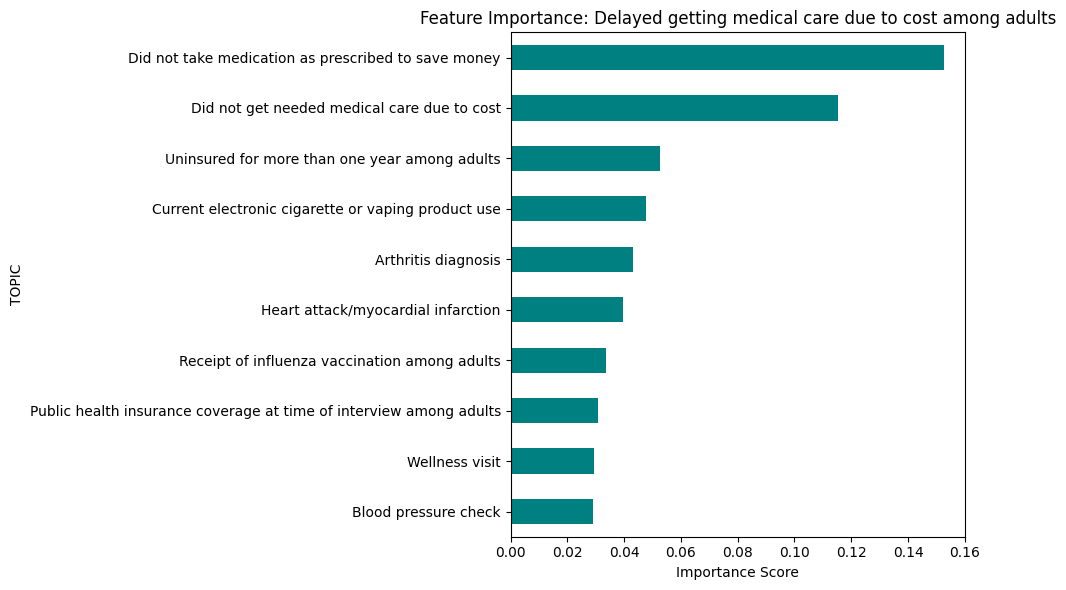

Model R² Score: 0.09


In [29]:
# 1. Define Target and Features
target_col = 'Delayed getting medical care due to cost among adults'

# FIX: Filter X to only include numeric columns and drop the target
# This automatically removes 'AI_Label', 'Cluster', and any other text columns
X = topic_df_filled.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')
y = topic_df_filled[target_col]

# 2. Train/Test Split
# (Make sure train_test_split and r2_score are imported)
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Extract Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot Top 10 Features
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='teal')
plt.title(f'Feature Importance: {target_col}')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png')
plt.show()

print(f"Model R² Score: {r2_score(y_test, rf.predict(X_test)):.2f}")

## Forecast Modeling

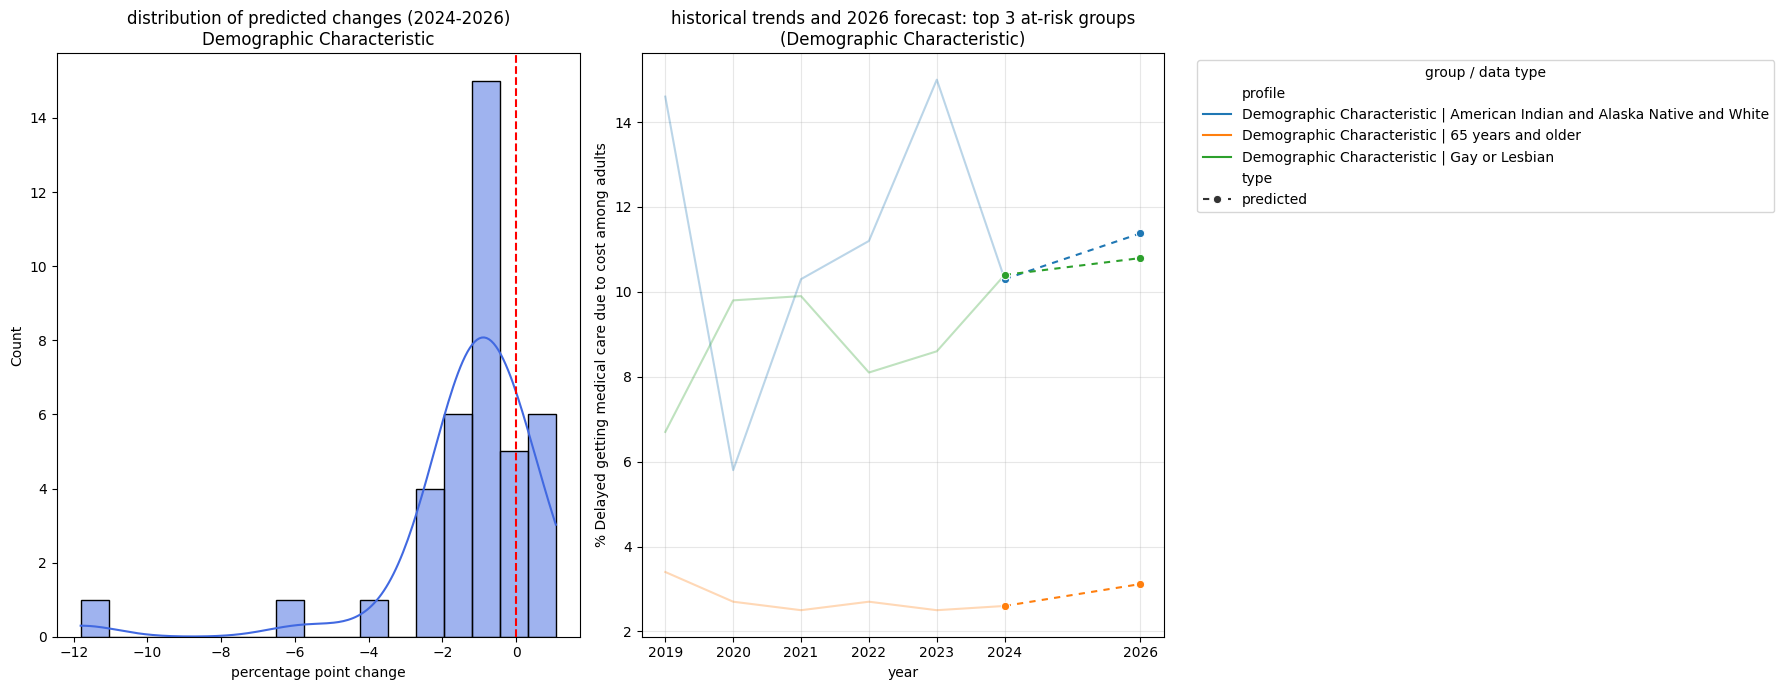

In [56]:
# @title 2026 delayed healthcare access forecast (2-year jump model)
# @markdown select which classification lens you want to view.
view_filter = "Demographic Characteristic" # @param ["Demographic Characteristic", "Socioeconomic Characteristic", "Geographic Characteristic"]

# exact string definitions from your dataset
target_topic = 'Delayed getting medical care due to cost among adults'

# feature selection function
def prepare_features(pivot_df, target_to_drop=None):
    temp_df = pivot_df.copy()
    temp_df = temp_df.select_dtypes(include=[np.number])

    # remove money and cost topics to prevent leakage
    forbidden_words = ['cost', 'money']
    cols_to_drop = [col for col in temp_df.columns if any(word in col.lower() for word in forbidden_words)]
    if target_to_drop and target_to_drop not in cols_to_drop:
        cols_to_drop.append(target_to_drop)
    temp_df = temp_df.drop(columns=cols_to_drop, errors='ignore')

    # return raw numeric features only without engineered interactions
    return temp_df

# pivot data and apply classification filter
years = sorted(df['TIME_PERIOD'].unique())
pivot_map = {}
for yr in years:
    df_yr = df[df['TIME_PERIOD'] == yr].copy()
    df_yr = df_yr[df_yr['CLASSIFICATION'] == view_filter]
    if df_yr.empty: continue

    # create unique profile index
    df_yr['Profile'] = df_yr.apply(lambda x: f"{x['CLASSIFICATION']} | {x['SUBGROUP']}" +
                                  (f" ({x['NESTING_LABEL']})" if pd.notnull(x['NESTING_LABEL']) else ""), axis=1)
    pivot_map[yr] = df_yr.pivot_table(index='Profile', columns='TOPIC', values='ESTIMATE').fillna(0)

# create 2-year jump training pairs
all_X, all_y = [], []
for i in range(len(years) - 2):
    curr_yr, jump_yr = years[i], years[i+2]
    if target_topic in pivot_map[jump_yr].columns:
        X_yr = prepare_features(pivot_map[curr_yr], target_to_drop=target_topic)
        y_yr = pivot_map[jump_yr][target_topic]
        common = X_yr.index.intersection(y_yr.index)
        if not common.empty:
            all_X.append(X_yr.loc[common]), all_y.append(y_yr.loc[common])

X_train_final = pd.concat(all_X)
y_train_final = pd.concat(all_y)

# train models on the 2-year gap logic
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train_final)

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_model.fit(X_train_final, y_train_final)

# direct forecast to 2026
model_features = rf_model.feature_names_in_
current_state_24 = prepare_features(pivot_map[2024], target_to_drop=target_topic).reindex(columns=model_features, fill_value=0)
pred_26 = (rf_model.predict(current_state_24) + xgb_model.predict(current_state_24)) / 2

# compile final summary
forecast_summary = pd.DataFrame({
    '2024_Actual': pivot_map[2024][target_topic],
    '2026_Pred': pred_26
}, index=pivot_map[2024].index)
forecast_summary['2yr_Change'] = forecast_summary['2026_Pred'] - forecast_summary['2024_Actual']

# visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# distribution plot
sns.histplot(forecast_summary['2yr_Change'].dropna(), kde=True, color='royalblue', ax=ax1)
ax1.axvline(0, color='red', linestyle='--')
ax1.set_title(f'distribution of predicted changes (2024-2026)\n{view_filter}')
ax1.set_xlabel('percentage point change')

# compile trajectory data for all historical years plus the 2026 forecast
top_groups = forecast_summary.sort_values('2yr_Change', ascending=False).head(3)
plot_data = []

for profile in top_groups.index:
    for yr in years:
        if profile in pivot_map[yr].index:
            plot_data.append({
                'profile': profile,
                'year': yr,
                'rate': pivot_map[yr].loc[profile, target_topic],
                'type': 'actual'
            })

    # bridge point
    if profile in pivot_map[2024].index:
        plot_data.append({
            'profile': profile,
            'year': 2024,
            'rate': pivot_map[2024].loc[profile, target_topic],
            'type': 'predicted'
        })

    plot_data.append({
        'profile': profile,
        'year': 2026,
        'rate': forecast_summary.loc[profile, '2026_Pred'],
        'type': 'predicted'
    })

trajectory_df = pd.DataFrame(plot_data)

# separate the data for specific transparency control
actual_df = trajectory_df[trajectory_df['type'] == 'actual']
pred_df = trajectory_df[trajectory_df['type'] == 'predicted']

# get standard color palette to match profiles across both plots
unique_profiles = top_groups.index.tolist()
palette = dict(zip(unique_profiles, sns.color_palette(n_colors=len(unique_profiles))))

# plot historical data with lower alpha (transparency)
sns.lineplot(
    data=actual_df,
    x='year', y='rate', hue='profile',
    palette=palette, markers=True, alpha=0.3, ax=ax2, legend=False
)

# plot predicted jump with full visibility and dashed lines
sns.lineplot(
    data=pred_df,
    x='year', y='rate', hue='profile',
    palette=palette, markers=True, style='type',
    dashes={'predicted': (3, 3)}, alpha=1.0, ax=ax2
)

ax2.set_title(f'historical trends and 2026 forecast: top 3 at-risk groups\n({view_filter})')
ax2.set_ylabel(f'% {target_topic}')
ax2.set_xlabel('year')
ax2.set_xticks(years + [2026])
ax2.grid(True, alpha=0.3)
ax2.legend(title='group / data type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()